In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle

url = r"C:\Users\R\Downloads\CAR_EVALUATION.csv"
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'target']
df = pd.read_csv(url, names=columns)

In [18]:
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [19]:
df = shuffle(df, random_state=42).reset_index(drop=True)

train_df = df.iloc[:1000]
val_df = df.iloc[1000:1300]
test_df = df.iloc[1300:]

X_train_full = train_df.drop('target', axis=1).values
y_train_full = train_df['target'].values
X_val = val_df.drop('target', axis=1).values
y_val = val_df['target'].values
X_test = test_df.drop('target', axis=1).values
y_test = test_df['target'].values

train_portions = np.arange(0.1, 1.1, 0.1)
val_accuracies = []
test_accuracies = []


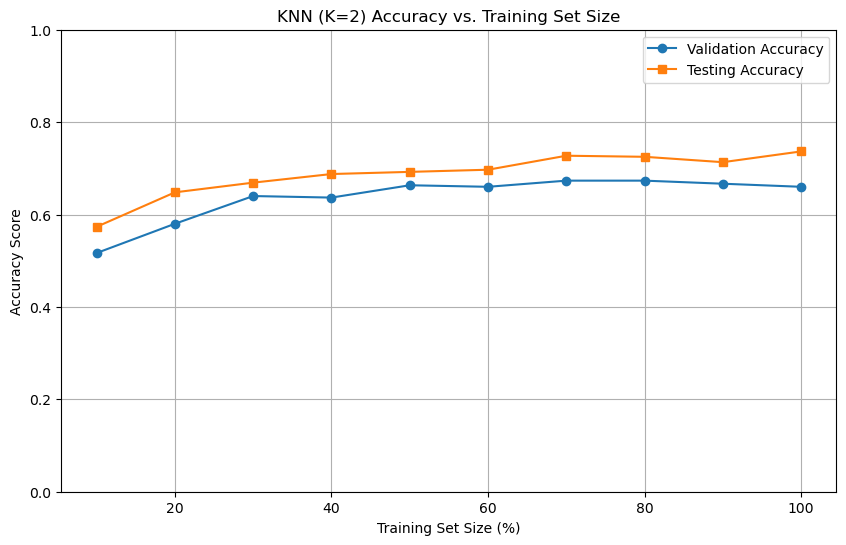

In [20]:
for portion in train_portions:
    sample_size = int(portion * len(X_train_full))
    X_train = X_train_full[:sample_size]
    y_train = y_train_full[:sample_size]
    
    knn = KNeighborsClassifier(n_neighbors=2)
    knn.fit(X_train, y_train)
    
    val_pred = knn.predict(X_val)
    test_pred = knn.predict(X_test)
    val_accuracies.append(accuracy_score(y_val, val_pred))
    test_accuracies.append(accuracy_score(y_test, test_pred))

plt.figure(figsize=(10, 6))
plt.plot(train_portions * 100, val_accuracies, label='Validation Accuracy', marker='o')
plt.plot(train_portions * 100, test_accuracies, label='Testing Accuracy', marker='s')
plt.xlabel("Training Set Size (%)")
plt.ylabel("Accuracy Score")
plt.title("KNN (K=2) Accuracy vs. Training Set Size")
plt.legend()
plt.grid(True)
plt.ylim(0, 1)
plt.show()

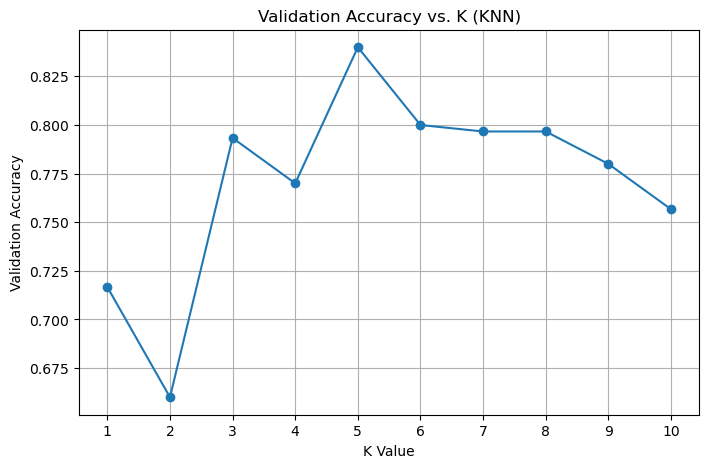

In [21]:
k_values = range(1, 11)
val_accuracies_k = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_full, y_train_full)
    val_pred = knn.predict(X_val)
    acc = accuracy_score(y_val, val_pred)
    val_accuracies_k.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(k_values, val_accuracies_k, marker='o')
plt.xlabel("K Value")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs. K (KNN)")
plt.xticks(k_values)
plt.grid(True)
plt.show()


10% Train, K=2: 0.046624 seconds
100% Train, K=2: 0.021991 seconds
10% Train, K=10: 0.022270 seconds
100% Train, K=10: 0.022266 seconds


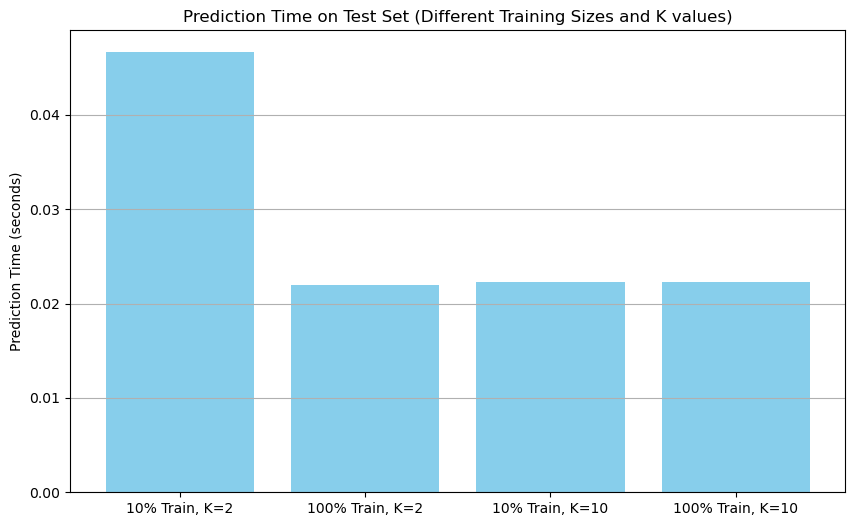

In [22]:
import time
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

cases = [
    ("10% Train, K=2", 0.1, 2),
    ("100% Train, K=2", 1.0, 2),
    ("10% Train, K=10", 0.1, 10),
    ("100% Train, K=10", 1.0, 10)
]

times = []

for label, portion, k in cases:
    sample_size = int(portion * len(X_train_full))
    X_train = X_train_full[:sample_size]
    y_train = y_train_full[:sample_size]
    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    start = time.time()
    _ = knn.predict(X_test)
    end = time.time()
    
    prediction_time = end - start
    times.append(prediction_time)
    print(f"{label}: {prediction_time:.6f} seconds")

plt.figure(figsize=(10, 6))
plt.bar([label for label, _, _ in cases], times, color='skyblue')
plt.ylabel("Prediction Time (seconds)")
plt.title("Prediction Time on Test Set (Different Training Sizes and K values)")
plt.grid(axis='y')
plt.show()
